In [269]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [270]:
RESULTS_PATH = Path(
    r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\fine_tuning_2\results\joint_summary_wide.csv"
)

df = pd.read_csv(RESULTS_PATH)
print("✅ CSV Loaded:", RESULTS_PATH)
print(df.head())
print(df.columns)

✅ CSV Loaded: C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\fine_tuning_2\results\joint_summary_wide.csv
    algo  candidate_id  seed  error                                json_path  \
0  joint           100   101    NaN  results\joint\runs\joint_c100_s101.json   
1  joint           100   202    NaN  results\joint\runs\joint_c100_s202.json   
2  joint           100   303    NaN  results\joint\runs\joint_c100_s303.json   
3  joint           100   404    NaN  results\joint\runs\joint_c100_s404.json   
4  joint           100   505    NaN  results\joint\runs\joint_c100_s505.json   

   best_final    auc_best  auc_best_norm  runtime_sec  evals_total  \
0     9625.15  944417.525     9444.17525  3414.346262         7900   
1     9598.55  949263.625     9492.63625  3480.763113         7900   
2     9647.95  951110.150     9511.10150  3496.837231         7900   
3     9569.80  941024.450     9410.24450  3456.755210         7900   
4     9609.20  944918.550     9449.18550  3509.0775

In [271]:
# ---------------------------------------------------
# 2) Sort + Inspect Best Runs (with full hyperparams)
# ---------------------------------------------------

df_sorted = df.sort_values(
    by=["best_final", "auc_best_norm"],
    ascending=[False, False],
    na_position="last"
)

TOP_N = 20  # puedes cambiarlo

cols_to_show = [
    # Identificadores
    "algo", "candidate_id", "seed",
    
    # Métricas clave
    "best_final", "auc_best_norm", "runtime_sec",
    
    # Hiperparámetros GA principales
    "cxpb", "mutpb", "mutation_rate",
    "parents_rate", "sel_mutation", "tail_mutation",
    
    # Config de población
    "generations", "popsize"
]

print(f"\n🏆 Top {TOP_N} Joint GA Runs (Metrics + Hyperparams):")
display(df_sorted[cols_to_show].head(TOP_N).style.background_gradient(cmap="viridis"))

# Best explicit
best_row = df_sorted.iloc[0]
print("\n✅ BEST RUN SELECTED:")
display(best_row[cols_to_show])



🏆 Top 20 Joint GA Runs (Metrics + Hyperparams):


c:\Users\57305\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning:

All-NaN slice encountered

c:\Users\57305\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning:

All-NaN slice encountered



,algo,candidate_id,seed,best_final,auc_best_norm,runtime_sec,cxpb,mutpb,mutation_rate,parents_rate,sel_mutation,tail_mutation,generations,popsize
476,joint,81,303,9687.800000,9573.737250,4728.938135,nan,nan,nan,0.149677,0.193508,0.017321,100,100
477,joint,81,404,9686.350000,9527.427250,4471.952737,nan,nan,nan,0.149677,0.193508,0.017321,100,100
478,joint,81,505,9682.150000,9533.874750,4444.171854,nan,nan,nan,0.149677,0.193508,0.017321,100,100
2,joint,100,303,9647.950000,9511.101500,3496.837231,nan,nan,nan,0.223424,0.332323,0.021376,100,100
441,joint,76,404,9641.350000,9499.624250,4044.293116,nan,nan,nan,0.189127,0.171513,0.032920,100,100
442,joint,76,505,9636.100000,9501.486500,4355.938236,nan,nan,nan,0.189127,0.171513,0.032920,100,100
443,joint,76,606,9635.700000,9512.472250,4235.833833,nan,nan,nan,0.189127,0.171513,0.032920,100,100
272,joint,50,303,9635.450000,9454.197000,3727.253674,nan,nan,nan,0.232434,0.401961,0.023927,100,100
479,joint,81,606,9633.800000,9536.477750,4003.701874,nan,nan,nan,0.149677,0.193508,0.017321,100,100
439,joint,76,202,9632.950000,9523.393750,4278.418297,nan,nan,nan,0.189127,0.171513,0.032920,100,100



✅ BEST RUN SELECTED:


algo                   joint
candidate_id              81
seed                     303
best_final            9687.8
auc_best_norm     9573.73725
runtime_sec      4728.938135
cxpb                     NaN
mutpb                    NaN
mutation_rate            NaN
parents_rate        0.149677
sel_mutation        0.193508
tail_mutation       0.017321
generations              100
popsize                  100
Name: 476, dtype: object

In [272]:
# =======================================================
# Aggregation by Candidate (6 seeds per candidate)
# =======================================================

agg = df.groupby("candidate_id").agg({
    "best_final": ["mean", "max"],
    "auc_best_norm": ["mean", "max"],
    "runtime_sec": "mean",
    "evals_total": "mean",
    "seed": "count"  # sanity check: should be 6
})

# Flatten MultiIndex columns
agg.columns = [
    f"{m}_{s}" if s != "" else m
    for m, s in agg.columns.map(lambda x: (x[0], "" if x[1] == "" else x[1]))
]

# Order by best performance + best stability
agg_sorted = agg.sort_values(
    by=["best_final_max", "auc_best_norm_max"],
    ascending=[False, False]
)

print("✅ Aggregated results by candidate:")
display(agg_sorted.head(10))


✅ Aggregated results by candidate:


,best_final_mean,best_final_max,auc_best_norm_mean,auc_best_norm_max,runtime_sec_mean,evals_total_mean,seed_count
candidate_id,,,,,,,
81,9655.283333,9687.80,9536.603083,9573.73725,4347.319520,8700.0,6
100,9613.175000,9647.95,9458.175458,9511.10150,3467.377100,7900.0,6
76,9626.025000,9641.35,9508.024542,9523.39375,4134.880146,8300.0,6
50,9590.841667,9635.45,9428.064375,9455.19350,3745.876097,7800.0,6
48,9600.675000,9630.55,9481.546292,9509.35550,3749.744136,7600.0,6
32,9588.791667,9614.60,9450.749792,9474.18750,3254.329761,6700.0,6
15,9548.558333,9584.40,9370.218792,9386.90525,2623.389406,5500.0,6
4,9558.866667,9583.75,9405.882667,9459.03175,2804.357001,5200.0,6
1,9561.708333,9581.10,9457.588875,9469.09300,4668.175347,8700.0,6


In [273]:

# Agregar métrica de eficiencia: AUC por evaluación
if "evals_total" in df.columns and "auc_best_norm" in df.columns:
    df["efficiency_auc_per_eval"] = df["auc_best_norm"] / df["evals_total"]
else:
    raise KeyError("Columns 'evals_total' and/or 'auc_best_norm' not found in DataFrame")

# Ordenar por desempeño global (AUC normalizado y fitness final)
df_sorted = df.sort_values(
    by=["best_final", "auc_best_norm"],
    ascending=[False, False],
    na_position="last"
)

TOP_N = 20  # número de ejecuciones a mostrar

cols_to_show = [
    # Identificadores
    "algo", "candidate_id", "seed",

    # Métricas clave
    "best_final", "auc_best_norm", "runtime_sec",
    "evals_total", "efficiency_auc_per_eval",

    # Hiperparámetros GA principales
    "cxpb", "mutpb", "mutation_rate",
    "parents_rate", "sel_mutation", "tail_mutation",

    # Config de población
    "generations", "popsize"
]

print(f"\n🏆 Top {TOP_N} Joint GA Runs (Metrics + Hyperparams):")
display(
    df_sorted[cols_to_show]
    .head(TOP_N)
    .style.format({"efficiency_auc_per_eval": "{:.6f}"})
    .background_gradient(cmap="viridis", subset=["efficiency_auc_per_eval"])
)

# Best explicit
best_row = df_sorted.iloc[0]
print("\n✅ BEST RUN SELECTED:")
display(best_row[cols_to_show])



🏆 Top 20 Joint GA Runs (Metrics + Hyperparams):


,algo,candidate_id,seed,best_final,auc_best_norm,runtime_sec,evals_total,efficiency_auc_per_eval,cxpb,mutpb,mutation_rate,parents_rate,sel_mutation,tail_mutation,generations,popsize
476,joint,81,303,9687.800000,9573.737250,4728.938135,8700,1.100430,nan,nan,nan,0.149677,0.193508,0.017321,100,100
477,joint,81,404,9686.350000,9527.427250,4471.952737,8700,1.095107,nan,nan,nan,0.149677,0.193508,0.017321,100,100
478,joint,81,505,9682.150000,9533.874750,4444.171854,8700,1.095848,nan,nan,nan,0.149677,0.193508,0.017321,100,100
2,joint,100,303,9647.950000,9511.101500,3496.837231,7900,1.203937,nan,nan,nan,0.223424,0.332323,0.021376,100,100
441,joint,76,404,9641.350000,9499.624250,4044.293116,8300,1.144533,nan,nan,nan,0.189127,0.171513,0.032920,100,100
442,joint,76,505,9636.100000,9501.486500,4355.938236,8300,1.144757,nan,nan,nan,0.189127,0.171513,0.032920,100,100
443,joint,76,606,9635.700000,9512.472250,4235.833833,8300,1.146081,nan,nan,nan,0.189127,0.171513,0.032920,100,100
272,joint,50,303,9635.450000,9454.197000,3727.253674,7800,1.212077,nan,nan,nan,0.232434,0.401961,0.023927,100,100
479,joint,81,606,9633.800000,9536.477750,4003.701874,8700,1.096147,nan,nan,nan,0.149677,0.193508,0.017321,100,100
439,joint,76,202,9632.950000,9523.393750,4278.418297,8300,1.147397,nan,nan,nan,0.189127,0.171513,0.032920,100,100



✅ BEST RUN SELECTED:


algo                             joint
candidate_id                        81
seed                               303
best_final                      9687.8
auc_best_norm               9573.73725
runtime_sec                4728.938135
evals_total                       8700
efficiency_auc_per_eval        1.10043
cxpb                               NaN
mutpb                              NaN
mutation_rate                      NaN
parents_rate                  0.149677
sel_mutation                  0.193508
tail_mutation                 0.017321
generations                        100
popsize                            100
Name: 476, dtype: object

In [274]:
best_candidate = agg_sorted.iloc[0]
cid = agg_sorted.index[0]

print("\n🏆 BEST CANDIDATE ✅")
print(f"Candidate ID: {cid}")
display(best_candidate)


🏆 BEST CANDIDATE ✅
Candidate ID: 81


best_final_mean       9655.283333
best_final_max        9687.800000
auc_best_norm_mean    9536.603083
auc_best_norm_max     9573.737250
runtime_sec_mean      4347.319520
evals_total_mean      8700.000000
seed_count               6.000000
Name: 81, dtype: float64

In [275]:
hp_cols = [
    "cxpb","mutpb","mutation_rate",
    "parents_rate","sel_mutation","tail_mutation",
    "generations","popsize"
]

best_hp = df[df["candidate_id"] == cid].iloc[0][hp_cols]
print("\n🎯 BEST Candidate Hyperparameters:")
display(best_hp)



🎯 BEST Candidate Hyperparameters:


cxpb                  NaN
mutpb                 NaN
mutation_rate         NaN
parents_rate     0.149677
sel_mutation     0.193508
tail_mutation    0.017321
generations           100
popsize               100
Name: 474, dtype: object

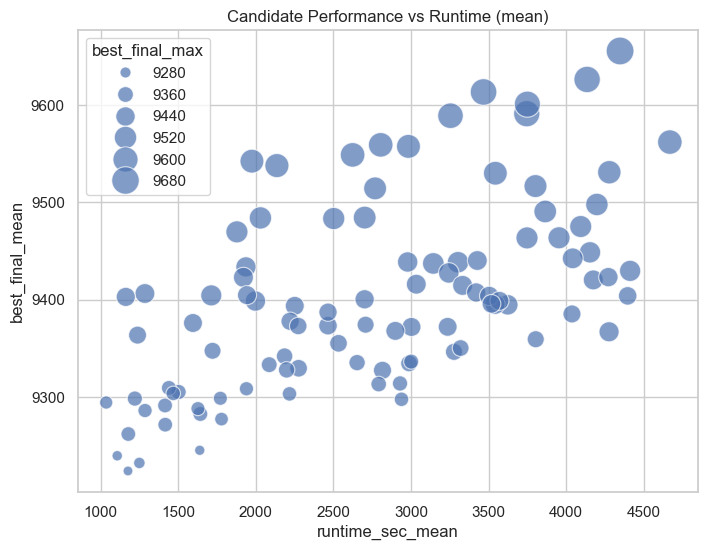

In [276]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=agg_sorted,
    x="runtime_sec_mean",
    y="best_final_mean",
    size="best_final_max",
    sizes=(50, 400),
    alpha=0.7
)
plt.title("Candidate Performance vs Runtime (mean)")
plt.grid(True)
plt.show()


In [277]:
# =======================================================
# Robust Selection under Low Sample Size (6 seeds)
# =======================================================

agg = df.groupby("candidate_id").agg({
    "best_final": ["mean", "std"],
    "auc_best_norm": ["mean", "std"],
    "runtime_sec": "mean"
}).reset_index()

agg.columns = ["candidate_id",
               "best_final_mean", "best_final_std",
               "auc_mean", "auc_std",
               "runtime_mean"]

# Normaliza métricas para comparabilidad
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
agg[["auc_mean_norm", "auc_std_norm"]] = scaler.fit_transform(
    agg[["auc_mean", "auc_std"]]
)

# Crea un score que combina rendimiento alto y estabilidad
agg["robust_score"] = agg["auc_mean_norm"] - agg["auc_std_norm"]

# Ordena según score robusto
agg_sorted = agg.sort_values(by="robust_score", ascending=False)

# Muestra top candidatos
print("🏆 Robust selection (AUC mean - AUC std dominance):")
display(
    agg_sorted.head(10)
    .style.format({
        "auc_mean": "{:.2f}",
        "auc_std": "{:.2f}",
        "robust_score": "{:.3f}"
    })
    .background_gradient(cmap="viridis", subset=["robust_score"])
)


🏆 Robust selection (AUC mean - AUC std dominance):


,candidate_id,best_final_mean,best_final_std,auc_mean,auc_std,runtime_mean,auc_mean_norm,auc_std_norm,robust_score
75,76,9626.025000,22.814179,9508.02,10.40,4134.880146,0.941298,0.025706,0.916
80,81,9655.283333,33.420782,9536.60,18.94,4347.319520,1.000000,0.183602,0.816
0,1,9561.708333,12.992052,9457.59,12.12,4668.175347,0.837699,0.057567,0.780
94,95,9516.525000,17.112912,9391.27,9.01,3802.108521,0.701483,0.000000,0.701
47,48,9600.675000,22.589705,9481.55,19.89,3749.744136,0.886910,0.201292,0.686
21,22,9530.741667,16.565127,9414.04,12.71,4277.961302,0.748244,0.068533,0.680
31,32,9588.791667,20.755828,9450.75,18.53,3254.329761,0.823651,0.176112,0.648
36,37,9423.016667,11.765104,9351.14,10.41,4271.943064,0.619047,0.026041,0.593
39,40,9484.175000,29.699844,9359.77,12.38,2701.187857,0.636763,0.062418,0.574
14,15,9548.558333,23.071290,9370.22,16.30,2623.389406,0.658235,0.134932,0.523


In [278]:
# =======================================================
# ✅ Aggregation by Candidate (Extended with Efficiency)
# =======================================================

agg = df.groupby("candidate_id").agg({
    "parents_rate": "mean",
    "sel_mutation": "mean",
    "tail_mutation": "mean",
    "best_final": ["mean", "max"],
    "auc_best_norm": ["mean", "max"],
    "runtime_sec": "mean",
    "evals_total": "mean",
    "seed": "count"  # should be 6
})

# Flatten MultiIndex columns
agg.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in agg.columns
]
agg = agg.reset_index()

# Rename for clarity
agg = agg.rename(columns={
    "parents_rate_mean": "parents_rate",
    "sel_mutation_mean": "sel_mutation",
    "tail_mutation_mean": "tail_mutation",
    "best_final_mean": "best_final_mean",
    "best_final_max": "best_final_max",
    "auc_best_norm_mean": "auc_mean",
    "auc_best_norm_max": "auc_max",
    "runtime_sec_mean": "runtime_mean",
    "evals_total_mean": "evals_mean",
    "seed_count": "n_runs"
})

# ✅ Add efficiency column: mean AUC per evaluation
agg["efficiency_mean"] = agg["auc_mean"] / agg["evals_mean"]

# Sorting by performance and efficiency
agg_sorted = agg.sort_values(
    by=["best_final_mean", "auc_mean", "efficiency_mean"],
    ascending=[False, False, False]
)

print("✅ Aggregated DataFrame ready with efficiency column!")
display(
    agg_sorted.head(10)
    .style.format({
        "efficiency_mean": "{:.6f}",
        "auc_mean": "{:.2f}",
        "best_final_mean": "{:.2f}",
        "runtime_mean": "{:.2f}"
    })
    .background_gradient(cmap="viridis", subset=["efficiency_mean"])
)


✅ Aggregated DataFrame ready with efficiency column!


,candidate_id,parents_rate,sel_mutation,tail_mutation,best_final_mean,best_final_max,auc_mean,auc_max,runtime_mean,evals_mean,n_runs,efficiency_mean
80,81,0.149677,0.193508,0.017321,9655.28,9687.800000,9536.60,9573.737250,4347.32,8700.000000,6,1.096161
75,76,0.189127,0.171513,0.032920,9626.02,9641.350000,9508.02,9523.393750,4134.88,8300.000000,6,1.145545
99,100,0.223424,0.332323,0.021376,9613.18,9647.950000,9458.18,9511.101500,3467.38,7900.000000,6,1.197237
47,48,0.250610,0.155499,0.036432,9600.68,9630.550000,9481.55,9509.355500,3749.74,7600.000000,6,1.247572
49,50,0.232434,0.401961,0.023927,9590.84,9635.450000,9428.06,9455.193500,3745.88,7800.000000,6,1.208726
31,32,0.348908,0.066789,0.028871,9588.79,9614.600000,9450.75,9474.187500,3254.33,6700.000000,6,1.410560
0,1,0.146225,0.166118,0.065189,9561.71,9581.100000,9457.59,9469.093000,4668.18,8700.000000,6,1.087079
3,4,0.497852,0.107807,0.038012,9558.87,9583.750000,9405.88,9459.031750,2804.36,5200.000000,6,1.808824
69,70,0.399619,0.173147,0.039401,9557.28,9564.100000,9408.79,9443.323500,2983.29,6200.000000,6,1.517547
14,15,0.462861,0.358562,0.012134,9548.56,9584.400000,9370.22,9386.905250,2623.39,5500.000000,6,1.703676


In [279]:
# =======================================================
# 🏅 Ranking: Top 10 Most Efficient Candidates
# =======================================================

if "efficiency_mean" not in agg_sorted.columns:
    raise KeyError("Column 'efficiency_mean' not found in aggregated DataFrame.")

# Crear ranking
top_efficient = (
    agg_sorted.sort_values(by="efficiency_mean", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_efficient.index += 1  # ranking 1..10

cols_eff = [
    "candidate_id", "best_final_mean", "auc_mean", "evals_mean",
    "efficiency_mean", "runtime_mean", "n_runs", "parents_rate",
    "sel_mutation", "tail_mutation",
]

print("\n🏆 Top 10 Most Efficient Candidates (AUC per Evaluation):")
display(
    top_efficient[cols_eff]
    .style.format({
        "efficiency_mean": "{:.6f}",
        "auc_mean": "{:.2f}",
        "best_final_mean": "{:.2f}",
        "evals_mean": "{:.0f}",
        "runtime_mean": "{:.2f}"
    })
    .background_gradient(cmap="viridis", subset=["efficiency_mean"])
)



🏆 Top 10 Most Efficient Candidates (AUC per Evaluation):


,candidate_id,best_final_mean,auc_mean,evals_mean,efficiency_mean,runtime_mean,n_runs,parents_rate,sel_mutation,tail_mutation
1,65,9294.23,9069.78,2200,4.122626,1035.26,6,0.798100,0.325799,0.070461
2,29,9239.56,9062.13,2300,3.940057,1106.32,6,0.787366,0.235964,0.249851
3,19,9402.72,9169.08,2400,3.820452,1161.45,6,0.774597,0.182531,0.024848
4,63,9261.90,9067.83,2400,3.778261,1177.86,6,0.779251,0.429945,0.030238
5,94,9406.17,9220.38,2500,3.688151,1284.66,6,0.763683,0.027410,0.054806
6,42,9223.93,9049.76,2500,3.619906,1175.57,6,0.766216,0.350242,0.211924
7,24,9363.46,9131.24,2600,3.512016,1237.23,6,0.756690,0.322966,0.012375
8,68,9298.28,9091.41,2600,3.496694,1219.83,6,0.750393,0.335680,0.133905
9,74,9232.18,9057.04,2700,3.354459,1248.85,6,0.742465,0.489548,0.072225
10,51,9286.00,9103.18,2800,3.251137,1285.45,6,0.734912,0.307495,0.166883


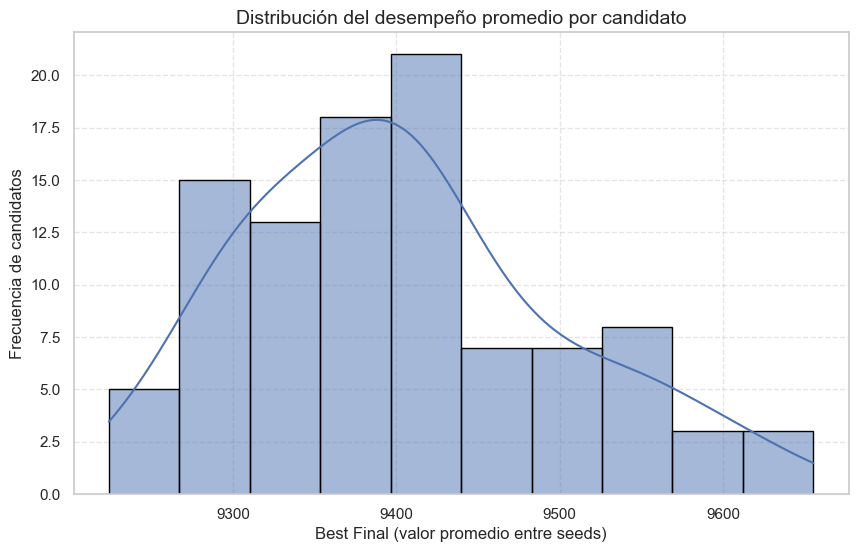

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(
    agg_sorted["best_final_mean"],
    kde=True,
    bins=10,
    edgecolor="black"
)

plt.title("Distribución del desempeño promedio por candidato", fontsize=14)
plt.xlabel("Best Final (valor promedio entre seeds)")
plt.ylabel("Frecuencia de candidatos")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


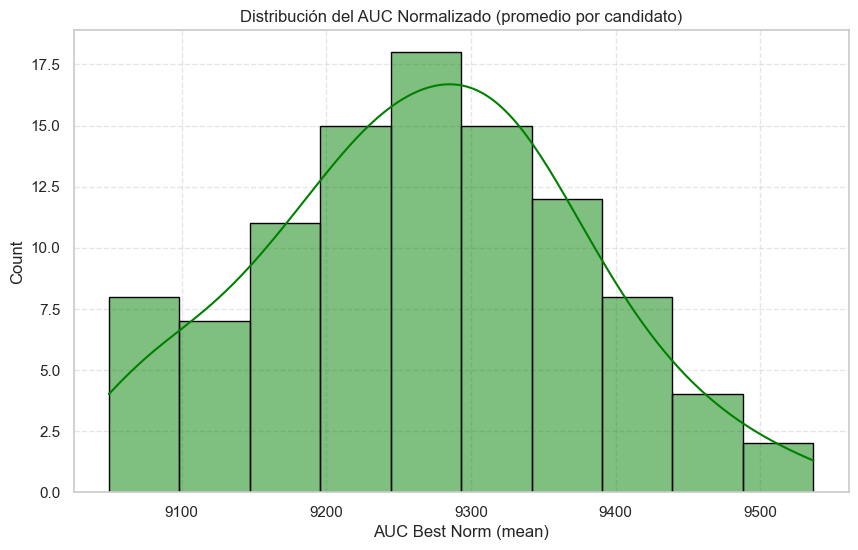

In [281]:
plt.figure(figsize=(10,6))
sns.histplot(
    agg_sorted["auc_mean"],
    kde=True,
    bins=10,
    edgecolor="black",
    color="green"
)

plt.title("Distribución del AUC Normalizado (promedio por candidato)")
plt.xlabel("AUC Best Norm (mean)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


=== Shapiro-Wilk Normality Test ===
Statistic: 0.9899
P-value : 0.658754
✅ No se rechaza H0 → La distribución puede considerarse Normal


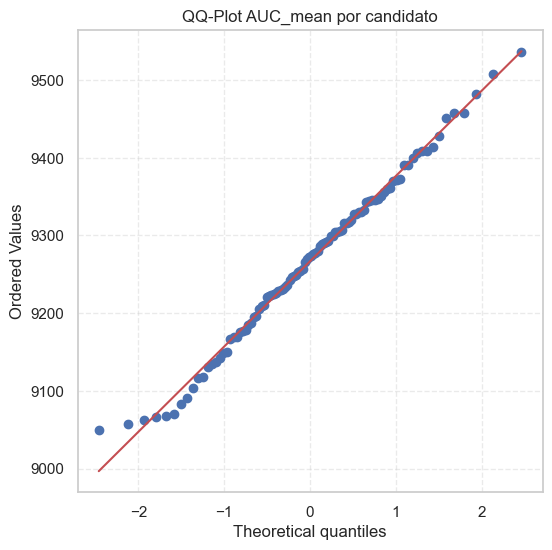

In [282]:
from scipy.stats import shapiro
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer la columna de interés
data_auc = agg_sorted["auc_mean"].dropna()

# --- Test Shapiro-Wilk ---
stat, p_value = shapiro(data_auc)

print("=== Shapiro-Wilk Normality Test ===")
print(f"Statistic: {stat:.4f}")
print(f"P-value : {p_value:.6f}")

alpha = 0.05
if p_value > alpha:
    print("✅ No se rechaza H0 → La distribución puede considerarse Normal")
else:
    print("❌ Se rechaza H0 → La distribución NO es Normal")


# --- QQ Plot for visual confirmation ---
plt.figure(figsize=(6,6))
stats.probplot(data_auc, dist="norm", plot=plt)
plt.title("QQ-Plot AUC_mean por candidato")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


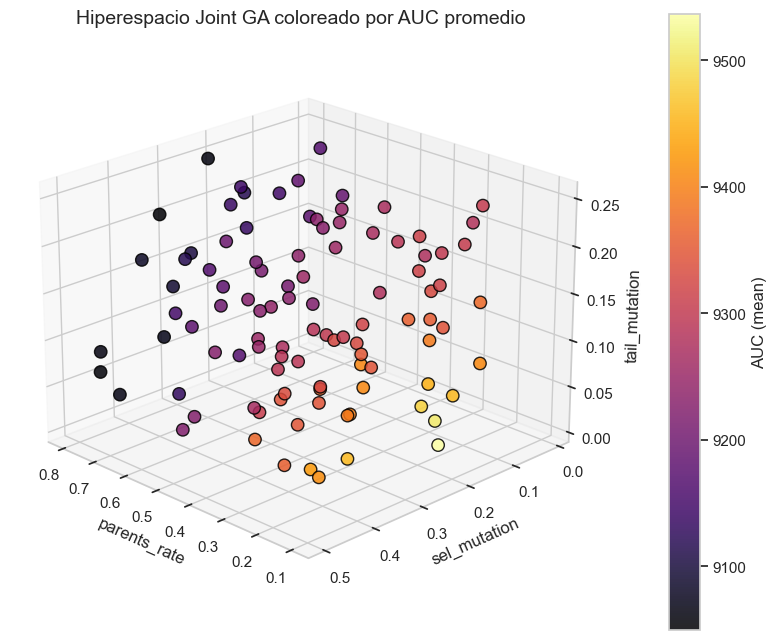

In [283]:
# ==================================================================
# 3D Scatter with AUC Heatmap Coloring (tipo el que mostraste)
# ==================================================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Data source
X = agg_sorted["parents_rate"]
Y = agg_sorted["sel_mutation"]
Z = agg_sorted["tail_mutation"]
C = agg_sorted["auc_mean"]  # 🔥 Colorear por desempeño AUC promedio

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Vista estilo heatmap
sc = ax.scatter(
    X, Y, Z,
    c=C,
    cmap="inferno",  # 🔥 igual estilo de tu ejemplo
    s=80,
    alpha=0.85,
    edgecolors="black"
)

# Labels
ax.set_xlabel("parents_rate")
ax.set_ylabel("sel_mutation")
ax.set_zlabel("tail_mutation")
ax.set_title("Hiperespacio Joint GA coloreado por AUC promedio", fontsize=14)

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("AUC (mean)")

# Opcional: mejor perspectiva
ax.view_init(elev=22, azim=135)

plt.show()


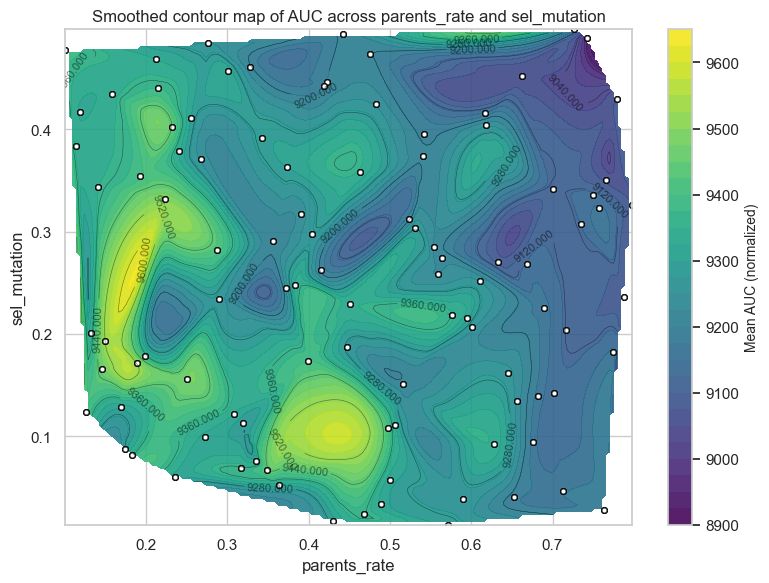

In [284]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

# --- Base data ---
# df must contain: ['parents_rate', 'sel_mutation', 'auc_best_norm']
x = df["parents_rate"].values
y = df["sel_mutation"].values
z = df["auc_best_norm"].values

# --- Create interpolation grid ---
xi = np.linspace(x.min(), x.max(), 150)
yi = np.linspace(y.min(), y.max(), 150)
xi, yi = np.meshgrid(xi, yi)

# Interpolate AUC surface
zi = griddata((x, y), z, (xi, yi), method="cubic")

# --- Plot smoothed heatmap + contour ---
plt.figure(figsize=(8, 6))

# Filled contour (heatmap)
contour = plt.contourf(
    xi, yi, zi,
    levels=30,
    cmap="viridis",
    alpha=0.9
)

# Contour lines
lines = plt.contour(
    xi, yi, zi,
    levels=10,
    colors="black",
    linewidths=0.4,
    alpha=0.5
)
plt.clabel(lines, inline=True, fontsize=8, fmt="%.3f")

# Optional scatter points (no labels)
plt.scatter(x, y, c="white", edgecolor="black", s=15, alpha=0.6)

# Colorbar and labels
cbar = plt.colorbar(contour)
cbar.set_label("Mean AUC (normalized)", fontsize=10)

# Axis labels and title
plt.title("Smoothed contour map of AUC across parents_rate and sel_mutation")
plt.xlabel("parents_rate")
plt.ylabel("sel_mutation")

# Axis limits
plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max())

plt.tight_layout()
plt.show()


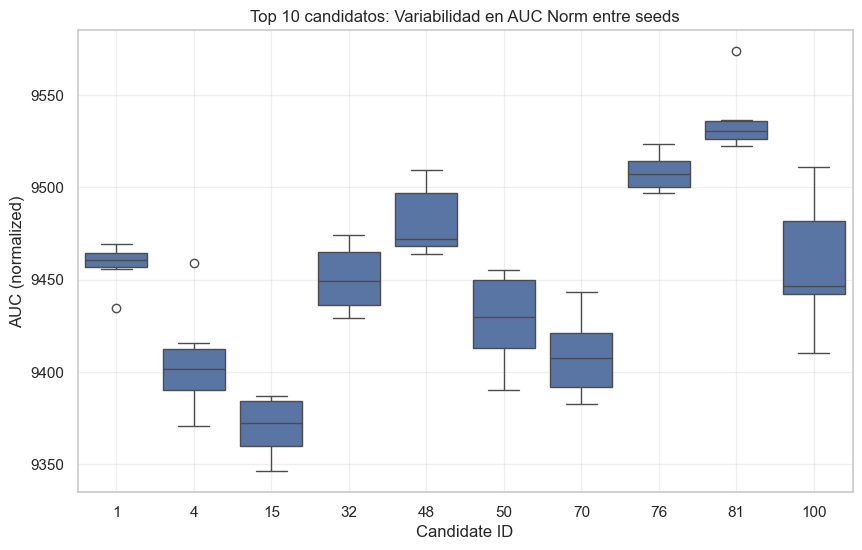

In [285]:
topN = agg_sorted.head(10)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df[df["candidate_id"].isin(topN["candidate_id"])],
    x="candidate_id",
    y="auc_best_norm"
)
plt.title("Top 10 candidatos: Variabilidad en AUC Norm entre seeds")
plt.xlabel("Candidate ID")
plt.ylabel("AUC (normalized)")
plt.grid(True, alpha=0.3)
plt.show()


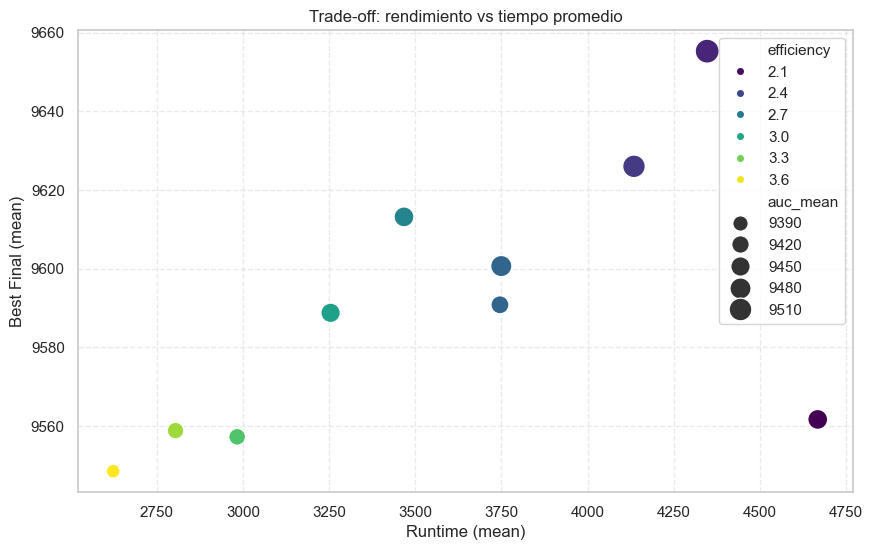

In [286]:
top10["efficiency"] = top10["best_final_mean"] / top10["runtime_mean"]

plt.figure(figsize=(10,6))
sns.scatterplot(
    x="runtime_mean",
    y="best_final_mean",
    hue="efficiency",
    size="auc_mean",
    sizes=(100,300),
    palette="viridis",
    data=top10
)
plt.title("Trade-off: rendimiento vs tiempo promedio")
plt.xlabel("Runtime (mean)")
plt.ylabel("Best Final (mean)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


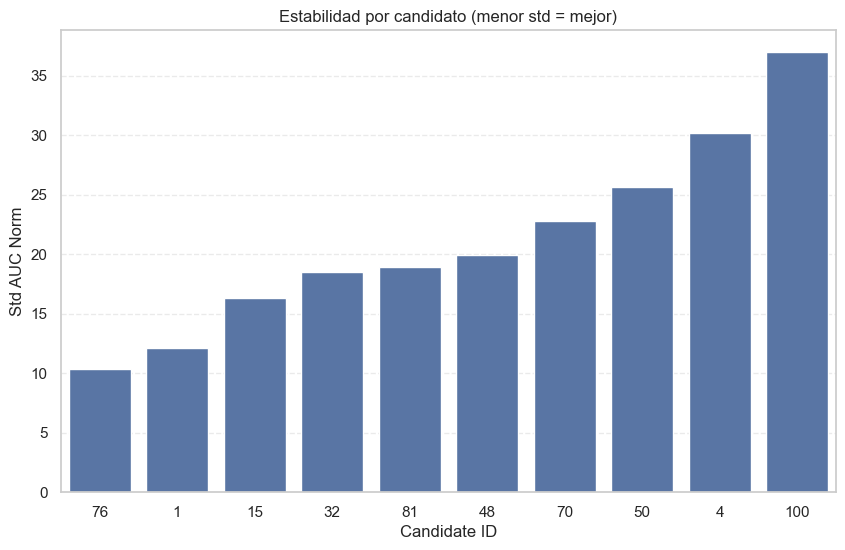

In [287]:
std_auc = df.groupby("candidate_id")["auc_best_norm"].std()

plt.figure(figsize=(10,6))
sns.barplot(
    x=std_auc.loc[top10["candidate_id"]].index,
    y=std_auc.loc[top10["candidate_id"]],
    order=std_auc.loc[top10["candidate_id"]]
         .sort_values()
         .index
)
plt.title("Estabilidad por candidato (menor std = mejor)")
plt.xlabel("Candidate ID")
plt.ylabel("Std AUC Norm")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


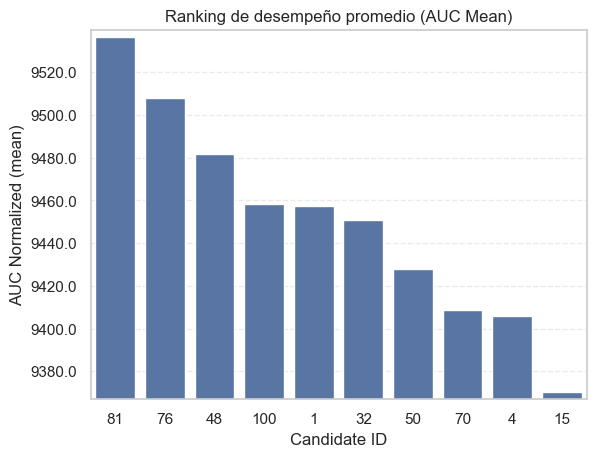

In [288]:
top10 = agg_sorted.head(10).copy()
order = top10.sort_values("auc_mean", ascending=False)["candidate_id"]

ax = sns.barplot(
    data=top10,
    x="candidate_id",
    y="auc_mean",
    order=order
)
ax.set_title("Ranking de desempeño promedio (AUC Mean)")
ax.set_xlabel("Candidate ID")
ax.set_ylabel("AUC Normalized (mean)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# 🔧 Ajuste de escala del eje Y
vmin = top10["auc_mean"].min()
vmax = top10["auc_mean"].max()
pad  = 0.02 * (vmax - vmin)  # 2% de margen
ax.set_ylim(vmin - pad, vmax + pad)

# (Opcional) menos decimales en ticks
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

plt.show()


# Analisis desde los JSON

In [289]:
import json
import pandas as pd
from pathlib import Path

# 📍 Cambia esta ruta según tu PC
runs_dir = Path(r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\fine_tuning_2\results\joint\runs")

rows = []
for f in runs_dir.glob("*.json"):
    with open(f, "r") as infile:
        data = json.load(infile)

    metrics = data["metrics"]
    diag_best = data["diagnostics"]["best"]
    hp = data["hparams"]

    rows.append({
        "file": f.name,
        "best_start": diag_best["start"],
        "best_final": diag_best["end"],
        "improvement_pct": diag_best["delta_rel"] * 100,
        "auc_norm": metrics["auc_best_norm"],
        "runtime_sec": metrics["runtime_sec"],
        "parents_rate": hp.get("parents_rate"),
        "sel_mut": hp.get("sel_mutation"),
        "tail_mut": hp.get("tail_mutation"),
    })

df = pd.DataFrame(rows)
print(df.head())


                   file  best_start  best_final  improvement_pct    auc_norm  \
0  joint_c100_s101.json     8352.80     9625.15        15.232617  9444.17525   
1  joint_c100_s202.json     8221.70     9598.55        16.746537  9492.63625   
2  joint_c100_s303.json     8307.85     9647.95        16.130527  9511.10150   
3  joint_c100_s404.json     8513.00     9569.80        12.413955  9410.24450   
4  joint_c100_s505.json     8520.30     9609.20        12.780066  9449.18550   

   runtime_sec  parents_rate   sel_mut  tail_mut  
0  3414.346262      0.223424  0.332323  0.021376  
1  3480.763113      0.223424  0.332323  0.021376  
2  3496.837231      0.223424  0.332323  0.021376  
3  3456.755210      0.223424  0.332323  0.021376  
4  3509.077520      0.223424  0.332323  0.021376  


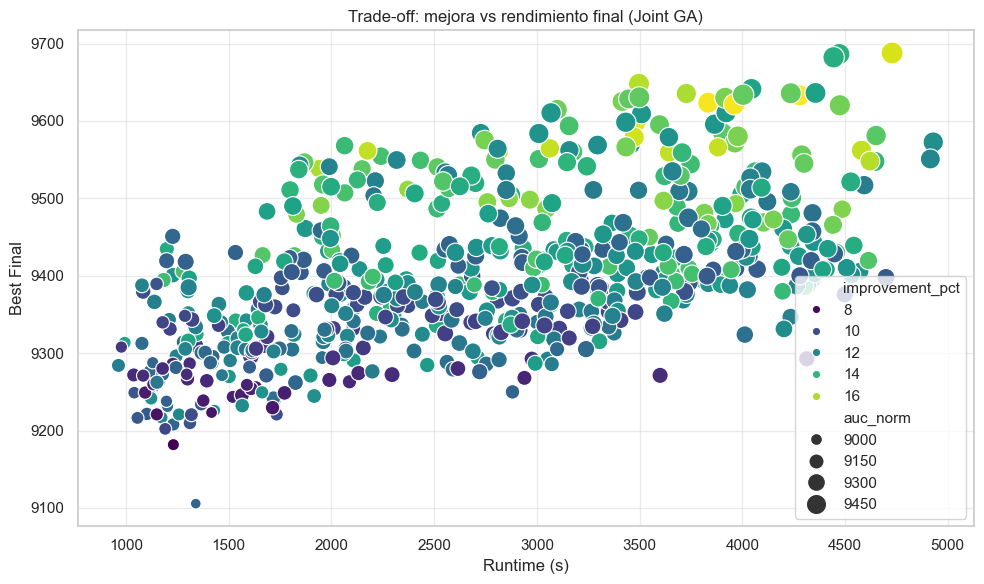

In [290]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="runtime_sec",
    y="best_final",
    hue="improvement_pct",
    size="auc_norm",
    sizes=(60,250),
    palette="viridis"
)

plt.title("Trade-off: mejora vs rendimiento final (Joint GA)")
plt.xlabel("Runtime (s)")
plt.ylabel("Best Final")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


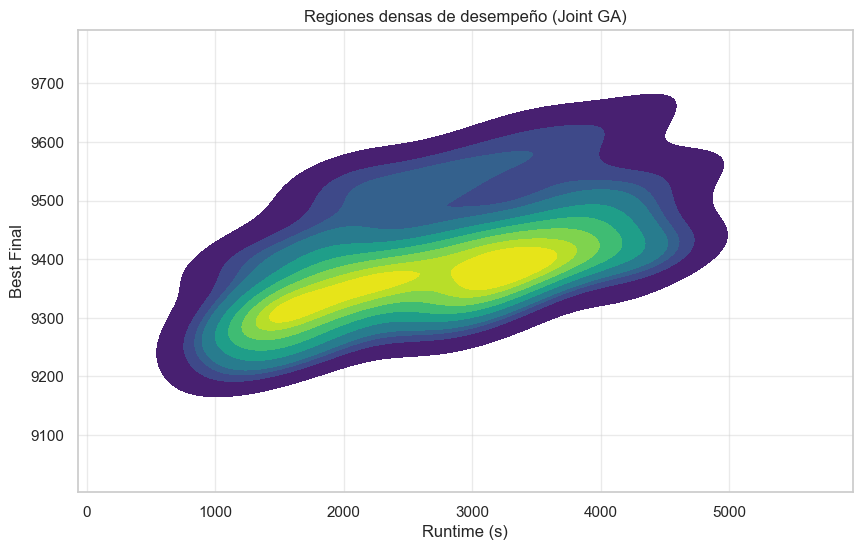

In [291]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x="runtime_sec",
    y="best_final",
    fill=True,
    cmap="viridis",
    thresh=0.05,
)
plt.title("Regiones densas de desempeño (Joint GA)")
plt.xlabel("Runtime (s)")
plt.ylabel("Best Final")
plt.grid(True, alpha=0.4)
plt.show()


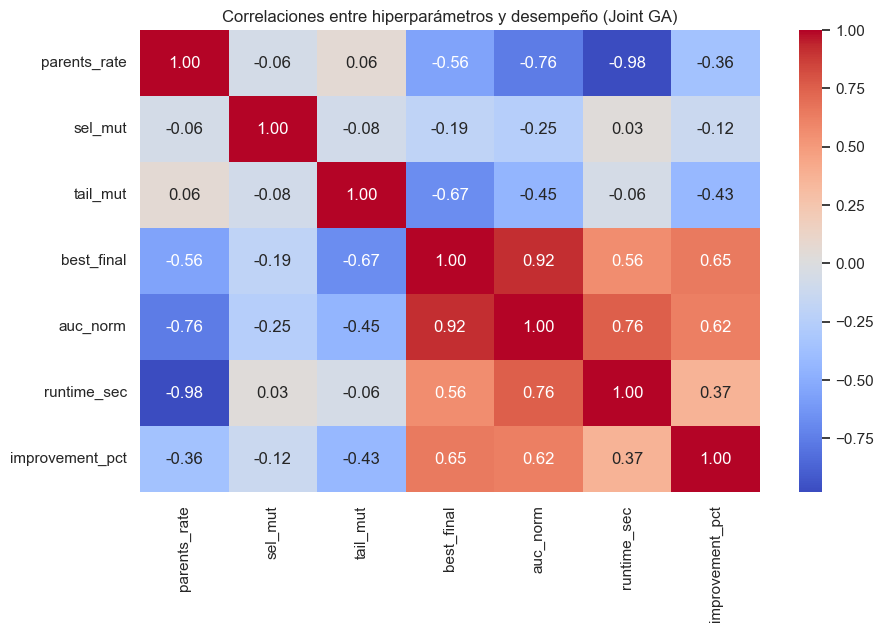

In [292]:
plt.figure(figsize=(10,6))

corr_cols = ["parents_rate", "sel_mut", "tail_mut", "best_final",
             "auc_norm", "runtime_sec", "improvement_pct"]

corr_df = df[corr_cols].corr()

sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre hiperparámetros y desempeño (Joint GA)")
plt.show()


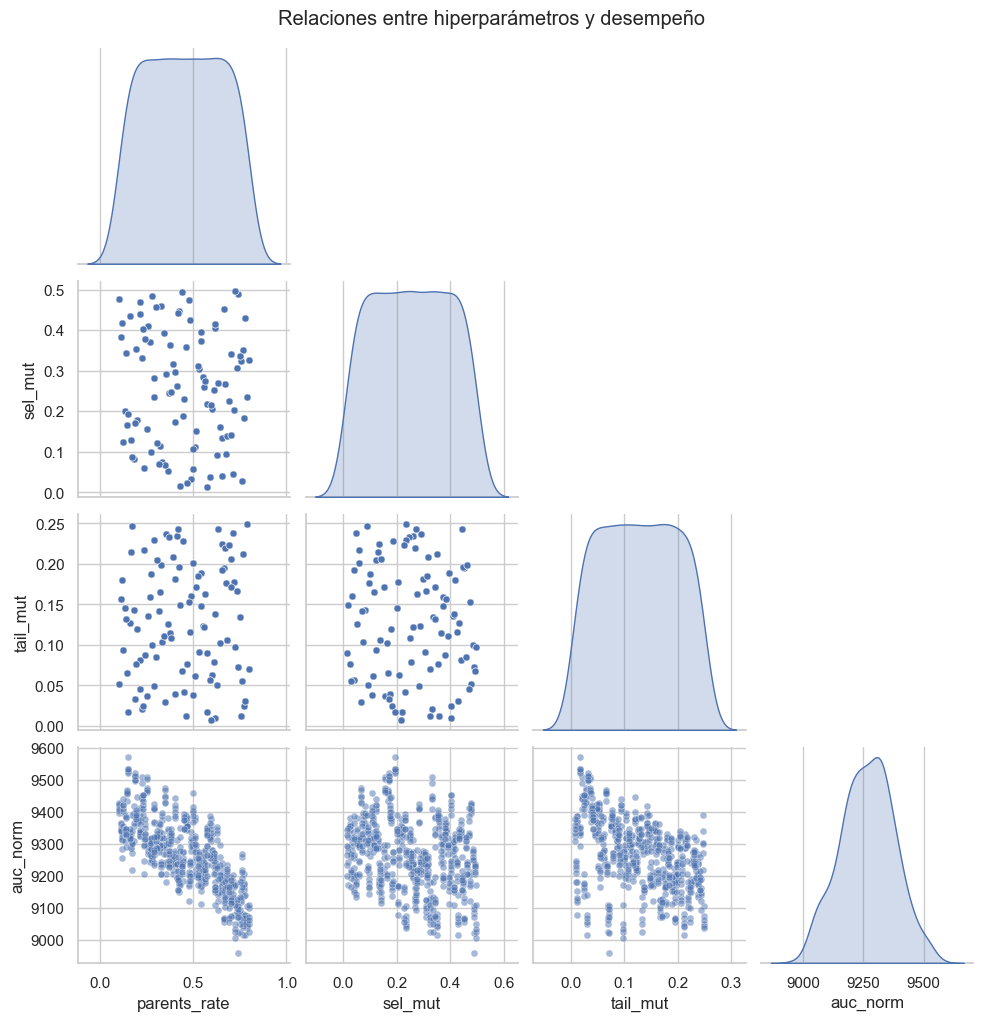

In [293]:
sns.pairplot(
    df[["parents_rate", "sel_mut", "tail_mut", "auc_norm"]],
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha":0.5, "s":25}
)
plt.suptitle("Relaciones entre hiperparámetros y desempeño", y=1.02)
plt.show()


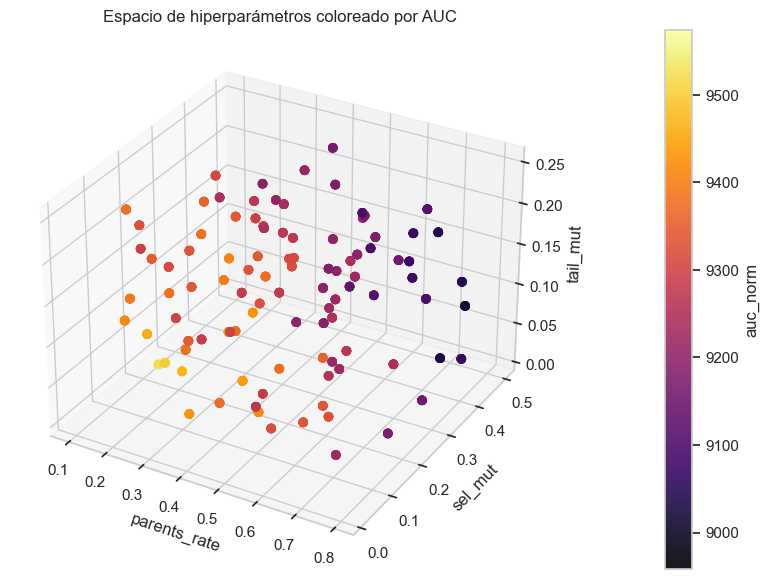

In [294]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["parents_rate"], df["sel_mut"], df["tail_mut"],
    c=df["auc_norm"], cmap="inferno", s=35, alpha=0.9
)

ax.set_xlabel("parents_rate")
ax.set_ylabel("sel_mut")
ax.set_zlabel("tail_mut")
ax.set_title("Espacio de hiperparámetros coloreado por AUC")

cbar = plt.colorbar(scatter, ax=ax, pad=.15)
cbar.set_label("auc_norm")
plt.show()


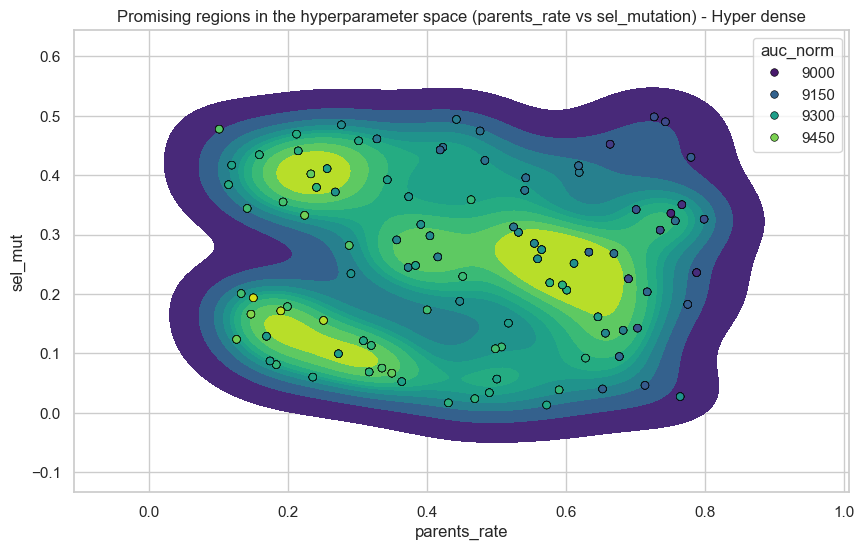

In [295]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x="parents_rate", y="sel_mut",
    fill=True, cmap="viridis", thresh=0.05
)
sns.scatterplot(
    data=df,
    x="parents_rate", y="sel_mut",
    hue="auc_norm",
    palette="viridis",
    edgecolor="black", s=30
)
plt.title("Promising regions in the hyperparameter space (parents_rate vs sel_mutation) - Hyper dense")
plt.show()


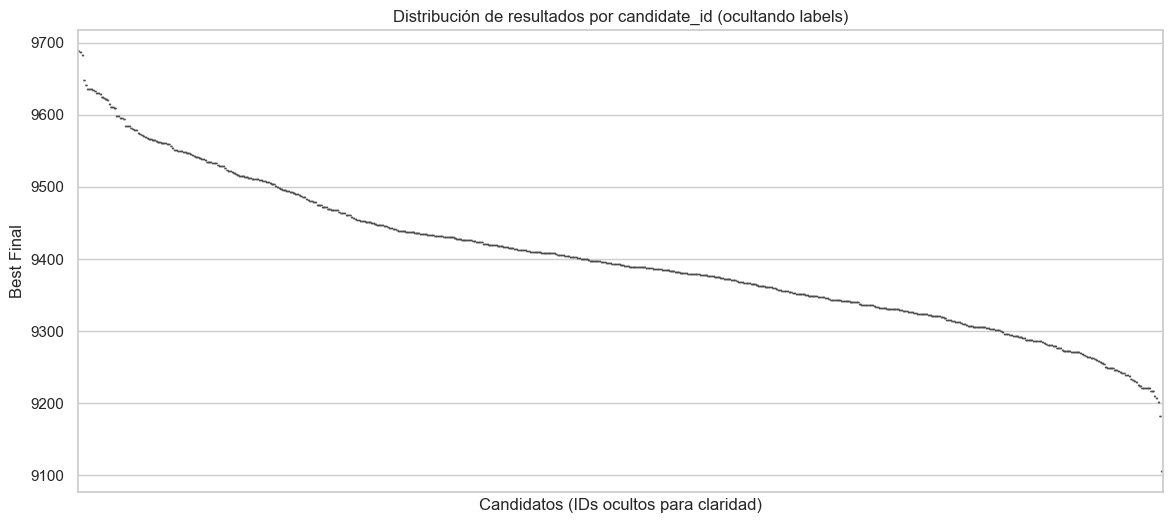

In [296]:
df_sorted = df.sort_values("best_final", ascending=False)

plt.figure(figsize=(14,6))
sns.boxplot(x="file", y="best_final", data=df_sorted)
plt.xticks([])
plt.title("Distribución de resultados por candidate_id (ocultando labels)")
plt.xlabel("Candidatos (IDs ocultos para claridad)")
plt.ylabel("Best Final")
plt.show()


In [297]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd

# 📍 Ruta a tus runs
runs_dir = Path(r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\fine_tuning_2\results\joint\runs")

runs_rows = []
curves_rows = []

rx = re.compile(r".*?_c(?P<cid>\d+)_s(?P<seed>\d+)\.json", re.I)

for f in runs_dir.glob("*.json"):
    with open(f, "r", encoding="utf-8") as fh:
        d = json.load(fh)

    m = rx.match(f.name)
    cid = int(m.group("cid")) if m else d.get("candidate_id")
    seed = int(m.group("seed")) if m else d.get("seed")

    hp = d.get("hparams", {})
    met = d.get("metrics", {})
    diag_best = d.get("diagnostics", {}).get("best", {})
    raw_best = (d.get("raw", {}).get("curves", {}) or {}).get("best", None)

    runs_rows.append({
        "candidate_id": cid,
        "seed": seed,
        "file": f.name,
        "best_start": diag_best.get("start"),
        "best_final": diag_best.get("end") or met.get("best_final"),
        "improvement_pct": (diag_best.get("delta_rel") or 0)*100,
        "auc_norm": diag_best.get("auc_norm") or met.get("auc_best_norm"),
        "runtime_sec": met.get("runtime_sec"),
        "parents_rate": hp.get("parents_rate"),
        "sel_mut": hp.get("sel_mutation"),
        "tail_mut": hp.get("tail_mutation"),
    })

    if raw_best:
        for g, val in enumerate(raw_best):
            curves_rows.append({
                "candidate_id": cid,
                "seed": seed,
                "gen": g,
                "best_curve": float(val)
            })

df_runs = pd.DataFrame(runs_rows)
df_curves = pd.DataFrame(curves_rows)

print("Runs:", df_runs.shape, "Curves:", df_curves.shape)
display(df_runs.head())
display(df_curves.head())


Runs: (600, 11) Curves: (60600, 4)


,candidate_id,seed,file,best_start,best_final,improvement_pct,auc_norm,runtime_sec,parents_rate,sel_mut,tail_mut
0,100,101,joint_c100_s101.json,8352.80,9625.15,15.232617,9444.17525,3414.346262,0.223424,0.332323,0.021376
1,100,202,joint_c100_s202.json,8221.70,9598.55,16.746537,9492.63625,3480.763113,0.223424,0.332323,0.021376
2,100,303,joint_c100_s303.json,8307.85,9647.95,16.130527,9511.10150,3496.837231,0.223424,0.332323,0.021376
3,100,404,joint_c100_s404.json,8513.00,9569.80,12.413955,9410.24450,3456.755210,0.223424,0.332323,0.021376
4,100,505,joint_c100_s505.json,8520.30,9609.20,12.780066,9449.18550,3509.077520,0.223424,0.332323,0.021376


,candidate_id,seed,gen,best_curve
0,100,101,0,8352.8
1,100,101,1,8510.3
2,100,101,2,9154.8
3,100,101,3,9163.2
4,100,101,4,9163.2


In [298]:
# Agregados por candidato (media/disp.) y #seeds
agg = df_runs.groupby("candidate_id").agg(
    best_final_mean=("best_final","mean"),
    best_final_std=("best_final","std"),
    auc_mean=("auc_norm","mean"),
    auc_std=("auc_norm","std"),
    runtime_mean=("runtime_sec","mean"),
    runtime_std=("runtime_sec","std"),
    parents_rate=("parents_rate","median"),
    sel_mut=("sel_mut","median"),
    tail_mut=("tail_mut","median"),
    seeds=("seed","nunique")
).reset_index().sort_values(["best_final_mean","auc_mean"], ascending=[False,False])

display(agg.head(10))

# Top-K 
TOP_K = 5
top_ids = agg.head(TOP_K)["candidate_id"].tolist()
print("Top IDs:", top_ids)


,candidate_id,best_final_mean,best_final_std,auc_mean,auc_std,runtime_mean,runtime_std,parents_rate,sel_mut,tail_mut,seeds
80,81,9655.283333,33.420782,9536.603083,18.935851,4347.319520,301.408991,0.149677,0.193508,0.017321,6
75,76,9626.025000,22.814179,9508.024542,10.395563,4134.880146,178.927665,0.189127,0.171513,0.032920,6
99,100,9613.175000,27.186702,9458.175458,36.970349,3467.377100,35.064673,0.223424,0.332323,0.021376,6
47,48,9600.675000,22.589705,9481.546292,19.892669,3749.744136,225.384590,0.250610,0.155499,0.036432,6
49,50,9590.841667,28.898312,9428.064375,25.655438,3745.876097,129.391997,0.232434,0.401961,0.023927,6
31,32,9588.791667,20.755828,9450.749792,18.530693,3254.329761,173.181210,0.348908,0.066789,0.028871,6
0,1,9561.708333,12.992052,9457.588875,12.118853,4668.175347,237.237915,0.146225,0.166118,0.065189,6
3,4,9558.866667,19.683563,9405.882667,30.225616,2804.357001,285.296499,0.497852,0.107807,0.038012,6
69,70,9557.283333,7.127739,9408.791333,22.774710,2983.287024,193.935300,0.399619,0.173147,0.039401,6
14,15,9548.558333,23.071290,9370.218792,16.303394,2623.389406,144.024579,0.462861,0.358562,0.012134,6


Top IDs: [81, 76, 100, 48, 50]


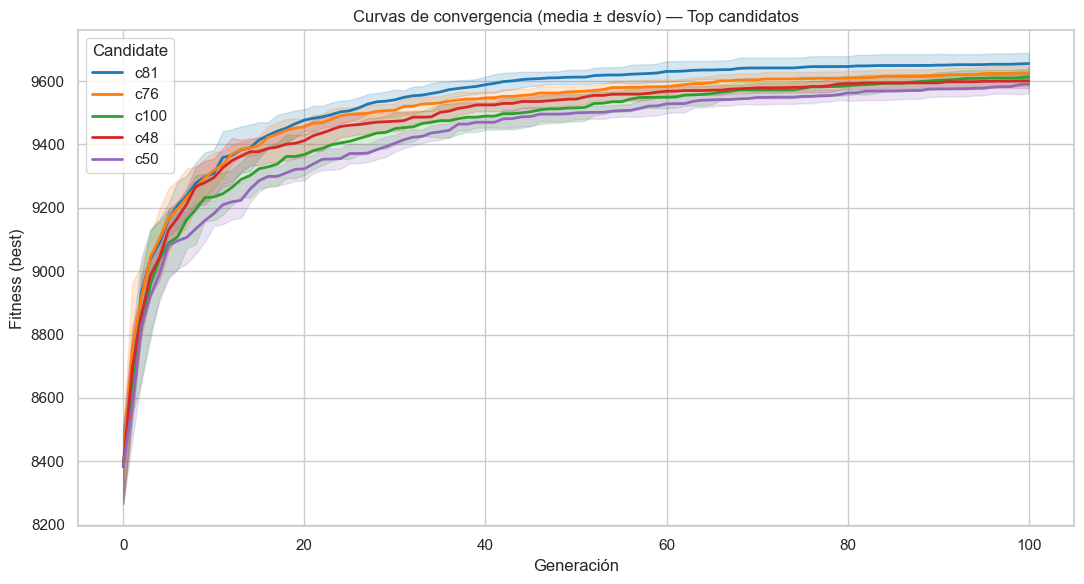

In [299]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Agregar por generación/candidato
curves_agg = (df_curves
              .query("candidate_id in @top_ids")
              .groupby(["candidate_id","gen"])
              .agg(mean=("best_curve","mean"),
                   std=("best_curve","std"))
              .reset_index())

pal = dict(zip(top_ids, sns.color_palette("tab10", n_colors=len(top_ids))))

plt.figure(figsize=(11,6))
for cid in top_ids:
    sub = curves_agg[curves_agg["candidate_id"]==cid]
    plt.plot(sub["gen"], sub["mean"], label=f"c{cid}", lw=2, color=pal[cid])
    plt.fill_between(sub["gen"], sub["mean"]-sub["std"], sub["mean"]+sub["std"],
                     alpha=0.18, color=pal[cid])

plt.title("Curvas de convergencia (media ± desvío) — Top candidatos")
plt.xlabel("Generación")
plt.ylabel("Fitness (best)")
plt.legend(title="Candidate")
plt.tight_layout(); plt.show()


# Experimentos.

In [300]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap


In [301]:

import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Any

# === CONFIG ===
runs_dir = Path(r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\fine_tuning_2\results\joint\runs")
E_STAR = 7300  # eval budget unificado

def slice_curve_at_eval(curve: List[float], evals_per_gen: List[int], E_star: int) -> float:
    """Interpolates the best-curve in eval steps to return the best value at E*."""
    cumulative = np.cumsum(evals_per_gen)
    idx = np.searchsorted(cumulative, E_star, side="right") - 1
    idx = max(0, min(idx, len(curve)-1))
    return curve[idx]

rows = []

for f in runs_dir.glob("*.json"):
    with open(f, "r") as fh:
        data = json.load(fh)

    cid = data.get("candidate_id")
    seed = data.get("seed")
    metrics = data["metrics"]
    hparams = data["hparams"]

    best_curve = data["raw"]["curves"]["best"]
    evals_gen = data["meta"]["evals_per_gen"]
    best_Estar = slice_curve_at_eval(best_curve, evals_gen, E_STAR)

    rows.append({
        "candidate_id": cid,
        "seed": seed,
        "best_final": metrics["best_final"],
        "auc_best": metrics["auc_best"],
        "evals_total": metrics["evals_total"],
        "best_at_E*": best_Estar,
        **hparams
    })

df_runs = pd.DataFrame(rows)
df_runs



,candidate_id,seed,best_final,auc_best,evals_total,best_at_E*,generations,popsize,fix_last_gene,verbosity,log_every,evals_cap,parents_rate,sel_mutation,tail_mutation
0,100,101,9625.15,944417.525,7900,9604.15,100,100,True,2,1,10000,0.223424,0.332323,0.021376
1,100,202,9598.55,949263.625,7900,9596.15,100,100,True,2,1,10000,0.223424,0.332323,0.021376
2,100,303,9647.95,951110.150,7900,9647.95,100,100,True,2,1,10000,0.223424,0.332323,0.021376
3,100,404,9569.80,941024.450,7900,9569.80,100,100,True,2,1,10000,0.223424,0.332323,0.021376
4,100,505,9609.20,944918.550,7900,9597.20,100,100,True,2,1,10000,0.223424,0.332323,0.021376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,9,202,9378.55,922597.225,5700,9378.55,100,100,True,2,1,10000,0.441818,0.493627,0.068111
596,9,303,9382.05,923039.000,5700,9382.05,100,100,True,2,1,10000,0.441818,0.493627,0.068111
597,9,404,9384.00,923812.450,5700,9384.00,100,100,True,2,1,10000,0.441818,0.493627,0.068111
598,9,505,9369.40,923003.650,5700,9369.40,100,100,True,2,1,10000,0.441818,0.493627,0.068111


In [302]:
agg = df_runs.groupby("candidate_id").agg(
    best_mean = ("best_at_E*", "mean"),
    best_std = ("best_at_E*", "std"),
    auc_mean = ("auc_best", "mean"),
    auc_std = ("auc_best", "std"),
    n_runs = ("seed", "count"),
    parents_rate=("parents_rate","first"),
    sel_mut=("sel_mutation","first"),
    tail_mut=("tail_mutation","first"),
).sort_values(by="best_mean", ascending=False)

agg.head(10)


,best_mean,best_std,auc_mean,auc_std,n_runs,parents_rate,sel_mut,tail_mut
candidate_id,,,,,,,,
81,9648.925000,35.566540,953660.308333,1893.585088,6,0.149677,0.193508,0.017321
76,9616.550000,19.872393,950802.454167,1039.556300,6,0.189127,0.171513,0.032920
100,9605.658333,26.110217,945817.545833,3697.034907,6,0.223424,0.332323,0.021376
48,9599.650000,21.069528,948154.629167,1989.266889,6,0.250610,0.155499,0.036432
32,9588.791667,20.755828,945074.979167,1853.069330,6,0.348908,0.066789,0.028871
50,9576.050000,24.818018,942806.437500,2565.543752,6,0.232434,0.401961,0.023927
4,9558.866667,19.683563,940588.266667,3022.561625,6,0.497852,0.107807,0.038012
70,9557.283333,7.127739,940879.133333,2277.471012,6,0.399619,0.173147,0.039401
1,9553.583333,14.563436,945758.887500,1211.885349,6,0.146225,0.166118,0.065189
